In [1]:
import pandas as pd
import numpy as np
import cv2
import pdfplumber
import pytesseract
from pdf2image import convert_from_path
import matplotlib.pyplot as plt
from PIL import Image
import re
import os
import platform
import rapidfuzz
import PIL
import unicodedata

In [2]:
train_data = pd.read_csv(r'data\train\train_data.csv')
train_data

,train_image_path,parent_company,company_name,supplier_name
0,20241224093637635.pdf_3.png,SPG,Knuedler,brinks
1,20241224093637635.pdf_5.png,new_company,NaN,cbc
2,20241224093637635.pdf_6.png,SPG,HEINE,cfticket
3,20241224093637635.pdf_7.png,SPG,Knuedler,foyer_assurances
4,20241224093637635.pdf_9.png,new_company,NaN,new_supplier
...,...,...,...,...
167,20250613144620432.pdf_18.png,SPG,Knuedler,leoenergie
168,20250613144620432.pdf_21.png,SPG,Knuedler,leoenergie
169,20250613144620432.pdf_24.png,SPG,Knuedler,new_supplier
170,20250613144620432.pdf_26.png,SPG,Knuedler,post_telecom


In [11]:
list_company = ['brinks','avocat a la cour','sdworx','muller & wegener','mettler','marc decker','3c payment',
                'vigicore','ibgraf','rentokil initial','foyer','nespresso','scheidt & bachman','uncos']

CHEMIN DE PYTESSERACT

In [3]:
#chemin de pytesseract.exe
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

In [ ]:
dk = pd.read_csv('data\list_company.csv')
dk.head(50)

In [162]:
directory_parent_match = dk.loc[dk['parent_company'] == 'SPG','parent_company'].values

directory_company_match = dk.loc[dk['company_name_invoice'] == 'PARKING_BOUILLON','company_name_registery'].values

directory_company_match
directory_parent_match

array(['SPG', 'SPG', 'SPG', 'SPG', 'SPG', 'SPG', 'SPG', 'SPG', 'SPG',
       'SPG', 'SPG', 'SPG', 'SPG', 'SPG', 'SPG', 'SPG', 'SPG', 'SPG',
       'SPG'], dtype=object)

In [167]:
directory_company_match = dk.loc[dk['company_name_invoice'] == 'PARKING_BOUILLON','company_name_registery'].values
directory_parent_match_2 = dk.loc[dk['company_name_invoice'] == 'PARKING_BOUILLON','parent_company'].values
print(f"parent:",directory_parent_match_2)
print(f"company:",directory_company_match)

parent: ['SPG']
company: ['BOUILLON']


In [4]:
company_name = ('SPG', 'BOUILLON')

In [5]:
dg = pd.read_csv('./data\supplier_copy.csv')
dg.head()

,entreprise,ID_TVA
0,agimex,LU30148542
1,atelier_de_reliure,LU32492171
2,BMW,LU21427047
3,3c_payment,LU28264772
4,LS_avocat_a_la_cour,LU23014984


In [35]:
dg = pd.read_csv('./data\supplier_copy.csv')
dg = dg.drop(['Unnamed: 0.1','Unnamed: 0'],axis = 1)
dg.sort_values(by="entreprise").to_csv('data\supplier_copy.csv',index=False)

In [19]:
dg.drop_duplicates().shape

(24, 2)

In [28]:
dg.sort_values(by="entreprise").to_csv('data\supplier_copy.csv')

In [9]:
directory_company_match = dk.loc[dk['company_name_invoice'] == company_name[1]].values

In [11]:
directory_company_match[0]

array(['BOUILLON', 'BOUILLON', 'LU10403280', 'SPG'], dtype=object)

data\output\new_company\elco\facture20250723_011900.pdf

In [ ]:

#conversion du chaque page du pdf en image
image_train = convert_from_path(r"data\input\facture20250723_150746.pdf",dpi=300)
plt.figure(figsize=(15,15))
plt.imshow(image_train[0])
plt.show()

In [ ]:
image_path = r"data\train\facture20250723_232502.pdf_1.png"
image_train = Image.open(image_path)
image_rgb = image_train.convert("RGB")

image_rgb_array = np.array(image_rgb)


hsv_image = cv2.cvtColor(image_rgb_array, cv2.COLOR_RGB2HSV)
lower_yellow = np.array([20,80,80])
upper_yellow = np.array([40,255,255])

mask = cv2.inRange(hsv_image, lower_yellow, upper_yellow)


mask_inv = cv2.bitwise_not(mask)

foreground = cv2.bitwise_and(image_rgb_array, image_rgb_array, mask=mask_inv)

background = np.full(image_rgb_array.shape, 245, dtype=np.uint8)

highlight_removed = cv2.bitwise_and(background, background, mask=mask)
result = cv2.add(foreground, highlight_removed)

Image.fromarray(result)
# mask = cv2.inRange(hsv_image, lower_yellow, upper_yellow)

# image_rgb_array[mask > 0] = [240, 240, 240]

# Image.fromarray(image_rgb_array)


In [ ]:
image_path = r"data\train\facture20250723_232502.pdf_1.png"
image_train = Image.open(image_path)
image_rgb = image_train.convert("RGB")

image_rgb_array = np.array(image_rgb)


hsv_image = cv2.cvtColor(image_rgb_array, cv2.COLOR_RGB2HSV)
lower_yellow = np.array([20,50,50])
upper_yellow = np.array([40,255,255])
mask = cv2.inRange(hsv_image, lower_yellow, upper_yellow)

image_rgb_array[mask > 0] = [240, 240, 240]

Image.fromarray(image_rgb_array)





In [ ]:
gray_image = cv2.cvtColor(np.array(image_rgb), cv2.COLOR_BGR2GRAY)

In [ ]:
text_1_bis = pytesseract.image_to_string(gray_image)

def clean_ocr_text(text):
    text = text.lower()
    text = unicodedata.normalize('NFKD', text)  # enlève accents
    text = text.encode('ascii', 'ignore').decode('utf-8')  # remove non-ascii
    text = text.replace("-", " ").replace("_", " ").replace("/n"," ")# standardise séparateurs
    
    text = re.sub(r"[^\w\s]", "", text)  # supprime ponctuation
    #text = re.sub(r"\s+", "", text)  # supprime tous les espaces (ou remplace par un espace si tu veux garder les mots)
    return text.strip()

In [ ]:
image_path = r"data\train\facture20250723_232502.pdf_1.png"
image_train = Image.open(image_path)
image_rgb = image_train.convert("RGB")

image_rgb_array = np.array(image_rgb)

# 2. Convertir en HSV pour détecter le jaune
hsv = cv2.cvtColor(image_rgb_array, cv2.COLOR_BGR2HSV)
lower_yellow = np.array([20, 80, 80])
upper_yellow = np.array([40, 255, 255])
mask_yellow = cv2.inRange(hsv, lower_yellow, upper_yellow)

# 3. Convertir en niveaux de gris pour détecter le texte
gray = cv2.cvtColor(image_rgb_array, cv2.COLOR_BGR2GRAY)
_, mask_text = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# 4. Ne conserver le jaune que là où il n'y a pas de texte
only_yellow = cv2.bitwise_and(mask_yellow, cv2.bitwise_not(mask_text))

# 5. Remplacer le jaune (hors texte) par du fond blanc
image_rgb_array[only_yellow > 0] = [255, 255, 255]

# 6. (optionnel) affichage ou enregistrement
# cv2.imwrite("cleaned_image.png", img)

gray_final = cv2.cvtColor(image_rgb_array, cv2.COLOR_BGR2GRAY)
Image.fromarray(gray_final)

In [190]:
text_2_bis = pytesseract.image_to_string(gray_final)

In [193]:
text_11 = clean_ocr_text(text_2_bis)

score_process = rapidfuzz.process.extractOne(text_11,clean_ocr_text('LU14673765'))
score_partial_ratio = rapidfuzz.fuzz.partial_ratio(text_11,
                                                    clean_ocr_text("bouillon"))
print(f"score_process: {score_process}")
print(f"score_partial_ratio {score_partial_ratio}")

score_process: ('l', 60.0, 0)
score_partial_ratio 75.0


In [194]:
import numpy as np
import cv2
from PIL import Image

# 1. Charger l'image
image_path = r"data\train\facture20250723_232502.pdf_1.png"
image_train = Image.open(image_path)
image_rgb = image_train.convert("RGB")

# 2. Convertir en tableau numpy (BGR pour OpenCV)
image_rgb_array = np.array(image_rgb)
image_bgr_array = cv2.cvtColor(image_rgb_array, cv2.COLOR_RGB2BGR)

# 3. Convertir en HSV pour détecter le jaune
hsv = cv2.cvtColor(image_bgr_array, cv2.COLOR_BGR2HSV)
lower_yellow = np.array([20, 80, 80])     # Tu peux baisser à 60 si trop agressif
upper_yellow = np.array([40, 255, 255])
mask_yellow = cv2.inRange(hsv, lower_yellow, upper_yellow)

# 4. Convertir en niveaux de gris pour détecter le texte
gray = cv2.cvtColor(image_bgr_array, cv2.COLOR_BGR2GRAY)
_, mask_text = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# 5. Ne supprimer le jaune que là où il n'y a pas de texte
only_yellow = cv2.bitwise_and(mask_yellow, cv2.bitwise_not(mask_text))

# 6. Remplacer le jaune par du blanc (sans toucher au texte)
image_bgr_array[only_yellow > 0] = [255, 255, 255]

# 7. Conversion finale en niveaux de gris pour OCR
gray_final = cv2.cvtColor(image_bgr_array, cv2.COLOR_BGR2GRAY)

# 8. Affichage PIL si besoin
Image.fromarray(gray_final).show()

# 9. (optionnel) Pour pytesseract :
# import pytesseract
# text = pytesseract.image_to_string(gray_final)
# print(text)


In [195]:
text_3_bis = pytesseract.image_to_string(gray_final)

In [196]:
text_12 = clean_ocr_text(text_3_bis)

score_process = rapidfuzz.process.extractOne(text_12,clean_ocr_text('LU14673765'))
score_partial_ratio = rapidfuzz.fuzz.partial_ratio(text_12,
                                                    clean_ocr_text("bouillon"))
print(f"score_process: {score_process}")
print(f"score_partial_ratio {score_partial_ratio}")

score_process: ('l', 60.0, 0)
score_partial_ratio 87.5


In [197]:
print(text_12)

date  03042025
facture 5401000260

 s  l e l ce co sales office esch sur alzette

 an equans company route de belval 371 l 4024   esch sur alzette
luxembourg 

tel 352 31 48 10   fax 352 31 48 11

e mail facturationsolelecjuequanscom

adresse du donneur dordre 

adresse envoi facture 

parkolux sa
24b avenue monterey parkolux sa
 r 24b avenue monterey
l 2162 luxembourg

adresse de chantier 

ne tva client lu10403280

n client  16478
vree  entretien 2024 2025 parkolux sa

nref  40m725  r 059934 100 24b avenue monterey
ncde  1295270 l 2162 luxembourg

contact administratiee  ludovic ochem
nrtelephone  352 691 950 399

vws ref  commande du 11122024

concerne  entretien annuel di parking boutllon 2024 2025

n ref  offre op 17 752 a loc du 22052017   tranche 3

poste article quantitee prix unitaire total hors tva

10 facturation 3ieme trimestre 0250 pce bo 65 2 561646 eur
bases  montant tva total tva incl

tva m8 561646 1700 95480 657126 bur

total aa payer 5 61646 95480 657126 eur

six mil

In [202]:
text_10 = clean_ocr_text(text_1_bis)

score_process = rapidfuzz.process.extractOne(text_10,clean_ocr_text('LU14673765'))
score_partial_ratio = rapidfuzz.fuzz.partial_ratio(text_10,
                                                    clean_ocr_text("parking bouillon"))
print(f"score_process: {score_process}")
print(f"score_partial_ratio {score_partial_ratio}")

score_process: ('l', 60.0, 0)
score_partial_ratio 87.5


In [200]:
print(text_10)

date  o03 042025
facture 5401000260

 s  l e l  c sales office esch sur alzette

 an equans company route de belval 371 l 4024   esch sur alzette
luxembourg 

tel 352 31 48 10   fax 352 31 48 11

e mail facturationsolelecjuequanscom

adresse du donneur dordre 

adresse envoi facture 

parkolux sa
24b avenue monterey parkolux sa
 r 24b avenue monterey
l 2162 luxembourg

adresse de chantier 

ne tva client lu10403280

n client  16478
vref  entretien 2024 2025 parkolux sa

nref  40m725  r 059934 100 24b avenue monterey
ncde  1295270 l 2162 luxembourg

contact administratiee  ludovic ochem
nrtelephone  352 691 950 399

vws ref  commande du 11122024

concerne  entretien annuel di parking boutlilon 2024 2025

n ref  offre op 17 752 a loc du 22052017   tranche 3

poste article quantitee prix unitaire total hors tva

10 facturation 3ieme trimestre 0250 pce 22 65 82 561646 eur
bases  montant tva total tva incl

tva m8 561646 lf oo 95480 657126 eur

total aa payer 561646 95480 657126 eur

six mi

In [ ]:


image_rgb = image_train[0].convert("RGB")

img_array = np.array(image_rgb)

#bilateral filter

filtered_image = cv2.bilateralFilter(img_array, 9, 75, 75)


gray_image = cv2.cvtColor(filtered_image, cv2.COLOR_BGR2GRAY)

 
adaptive_threshold = cv2.adaptiveThreshold(gray_image, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 25, 10)

#Image.fromarray(adaptive_threshold)

text_1 = pytesseract.image_to_string(adaptive_threshold)

In [103]:
def clean_ocr_text(text):
    text = text.lower()
    text = unicodedata.normalize('NFKD', text)  # enlève accents
    text = text.encode('ascii', 'ignore').decode('utf-8')  # remove non-ascii
    text = text.replace("-", " ").replace("_", " ").replace("/n"," ")# standardise séparateurs
    
    text = re.sub(r"[^\w\s]", "", text)  # supprime ponctuation
    #text = re.sub(r"\s+", "", text)  # supprime tous les espaces (ou remplace par un espace si tu veux garder les mots)
    return text.strip()


text_9 = clean_ocr_text(text_1)

score_process = rapidfuzz.process.extractOne(text_9,clean_ocr_text('LU14673765'))
score_partial_ratio = rapidfuzz.fuzz.partial_ratio(text_9,
                                                    clean_ocr_text('societe du parking desch sur alzette'))
print(f"score_process: {score_process}")
print(f"score_partial_ratio {score_partial_ratio}")

score_process: ('l', 60.0, 0)
score_partial_ratio 91.66666666666666


In [99]:
print(text_9)

silica

bmw dealer

facture atelier

n document 2sp12503187
date document 270325
date decheance 270325
n commande 2502503166

page 1

bmiv service

societe du parking ag
desch sur alzette
24bavenue monterey
2163 luxembourg

client commande beck serge 1 op bierg 8217 mamer

a ns

code marque chassis kilometrage
bmw wbatrsso6gonc8704 106848
modele code modele n immat
trsos trsos5 bs1020

n designation

fpahrzaugtest durchfluhran
oo0o0006 realiser un test vehicule
6121528 supporter la tension du reseau de

bord  recharger

la batterie du reseau de bord
6100006 executer le module de test de

diagnostic du vehicu

le

petites fournlitures

conditions de paiement
comm structuree

paiement comptant

luxembourg
n client 211783
n entreprise lu2oss8s8988
contact atelier date rendez vous
carlos carvalho 270325
immat initiale cree par
071118 carlos carvalho
qtre unite prix unitalire montant
g vt 1208 4833
1 vt 1208 1208
4 vt 1208 4833
1 218 218
total mo 10874
total autres 218
total eur 11092
tva 1

In [49]:
text_1

'ASSOCIATION LUXENMBOURGEOISE DE FOOTGOLF\n\n- OFFICIAL MEMBER -\n\nFACTURE FO2 spssa\n\n24b Av. Monterey\nTél : 691 673 978 L-2163 — LUXEMBOURG\nluxfootgolf@gmail.com\n\n35-39, Grand-rue Date : O03 mars 2025\nL-4575 Differdange\n\nConcerne: Sponsoring 2025\n\nBanque :\n\nBanque Raiffeisen s.c. :\n\nBIC : CGRALULL aPrixta\nLU63 0099 7800 0139 0038 Foniksé\n\nSPONSORING (Lux-Open)\n\nous-total\n\n: Total TTC\n\nNous vous remercions pour votre confiance.\n\naCoat\n\nH\n\n1200,00 €\n1200,00 ©\n1200,00 €\n\nVERIFIE LE U3? £25 2025\n\nClassification: Restricted distribution\n\na\n'

In [27]:
import unicodedata
import re
import rapidfuzz


text_2 = text_1.lower()
#print(text_2)
text_3 = unicodedata.normalize('NFKD',text_2)
# print(text_3)
text_4 = text_3.encode('ASCII','ignore').decode('utf-8')
# print(text_4)

text_5 = text_4.replace("-", " ").replace("_", " ")
# print(text_6)

text_6 = re.sub(r"[^\w\s]", "", text_5)  # supprime ponctuation
text_7 = re.sub(r"\s+", "", text_6)  # supprime tous les espaces (ou remplace par un espace si tu veux garder les mots)
text_8 = text_7.strip()

best_match,score_process,_ = rapidfuzz.process.extractOne(text_8,['parkingtheatre'])


score_partial_ratio = rapidfuzz.fuzz.partial_ratio(text_8,['worldline'])
print(f"score_process: {score_process}")
print(f"score_partial_ratio {score_partial_ratio}")

score_process: 60.0
score_partial_ratio 0.0


In [23]:
import unicodedata

In [32]:
def clean_ocr_text(text):
    text = text.lower()
    text = unicodedata.normalize('NFKD', text)  # enlève accents
    text = text.encode('ascii', 'ignore').decode('utf-8')  # remove non-ascii
    text = text.replace("-", " ").replace("_", " ")  # standardise séparateurs
    text = re.sub(r"[^\w\s]", "", text)  # supprime ponctuation
    #text = re.sub(r"\s+", "", text)  # supprime tous les espaces (ou remplace par un espace si tu veux garder les mots)
    return text.strip()

In [34]:
text_9 = clean_ocr_text(text_1)

In [35]:
text_9

'votre contact vos references\n\ngestionnaire licu de consommation nom client societe du parking avenue monterey sa\nraul marques 24a avenue monterey tarif moyenne tension 20 kv\ntel  2639 4812 l 2163 luxembourg\n\nrmarquesleoenergyu\nn installation 40 462 920\ndepannage  8002 9900\n\nsociete du parking avenue monterey sa\n24b avenue monterey\nl 2163 luxembourg\n\nqlixembourgenergy offical\nenovos group\n\nfacture delectricite a   decompte mensuel\npour la periode du 01 decembre 2024 au 31 decembre 2024 luxembourg le 31 decembre 2024\n\nn facture n client compte client\n1371 706 449 1262 807 810 000 898\n\ndate decheance 30012025\n\nhtva  tva  tva  tic \nfourniture delectricite moyenne tension 3 48875 8  27910 3 76785\n\nes sa\n\ntotal decompte 3 76785\ntotal a payer 3 76785\n\nle montant de cette facture sera preleve automatiquement de votre compte en banque ou ccp 3 la date decheance\n\nconformement a la lol modifiee du 18 avril 2004 relative aux delais de palement et aux interets de

In [45]:
score_process = rapidfuzz.process.extractOne(text_9,clean_ocr_text('LU14673765'))
score_partial_ratio = rapidfuzz.fuzz.partial_ratio(text_9,
                                                    clean_ocr_text('leoenergy'))
print(f"score_process: {score_process}")
print(f"score_partial_ratio {score_partial_ratio}")

score_process: ('l', 60.0, 0)
score_partial_ratio 100.0


In [141]:
clean_ocr_text('LU22991326') in text_9

True

In [93]:
clean_ocr_text('LU391111700891660000') in text_8

False

In [177]:
score_process = rapidfuzz.process.extractOne(text_9,clean_ocr_text("parking de l'avenue monterey"))
score_partial_ratio = rapidfuzz.fuzz.partial_ratio(text_9,
                                                    clean_ocr_text("parking de l'avenue monterey"))
print(f"score_process: {score_process}")
print(f"score_partial_ratio {score_partial_ratio}")

score_process: ('p', 60.0, 0)
score_partial_ratio 100.0


LU391111700891660000

In [62]:
type(score_partial_ratio)

float

In [ ]:
[parking_du_theatre,parking_theatre,theatre,SPT_SA]

In [ ]:
from rapidfuzz import process


best_match,score,_ = process.extractOne(text_6,['parkingtheatre'])
best_match,score,_ 

('parkingtheatre', 55.714285714285715, 0)

In [ ]:
import unicodedata
import re
import rapidfuzz


text_2 = text_1.lower()
#print(text_2)
text_3 = unicodedata.normalize('NFKD',text_2)
# print(text_3)
text_4 = text_3.encode('ASCII','ignore')
# print(text_4)

text_5 = text_4.decode('utf-8')
# print(text_5)

text_6 = text_5.replace("-", " ").replace("_", " ")
# print(text_6)

best_match,score_process,_ = process.extractOne(text_6,['parkingtheatre'])
best_match,score_process,_ 

score_partial_ratio = rapidfuzz.fuzz.partial_ratio(text_6,['parkingtheatre'])
print(f"score_process: {score_process}")
print(f"score_partial_ratio {score_partial_ratio}")

NEW_TEST PYTESSERACT

In [7]:
def clean_ocr_text(text):
    text = text.lower()
    text = unicodedata.normalize('NFKD', text)  # enlève accents
    text = text.encode('ascii', 'ignore').decode('utf-8')  # remove non-ascii
    text = text.replace("-", " ").replace("_", " ").replace("/n"," ")# standardise séparateurs
    
    text = re.sub(r"[^\w\s]", "", text)  # supprime ponctuation
    #text = re.sub(r"\s+", "", text)  # supprime tous les espaces (ou remplace par un espace si tu veux garder les mots)
    return text.strip()

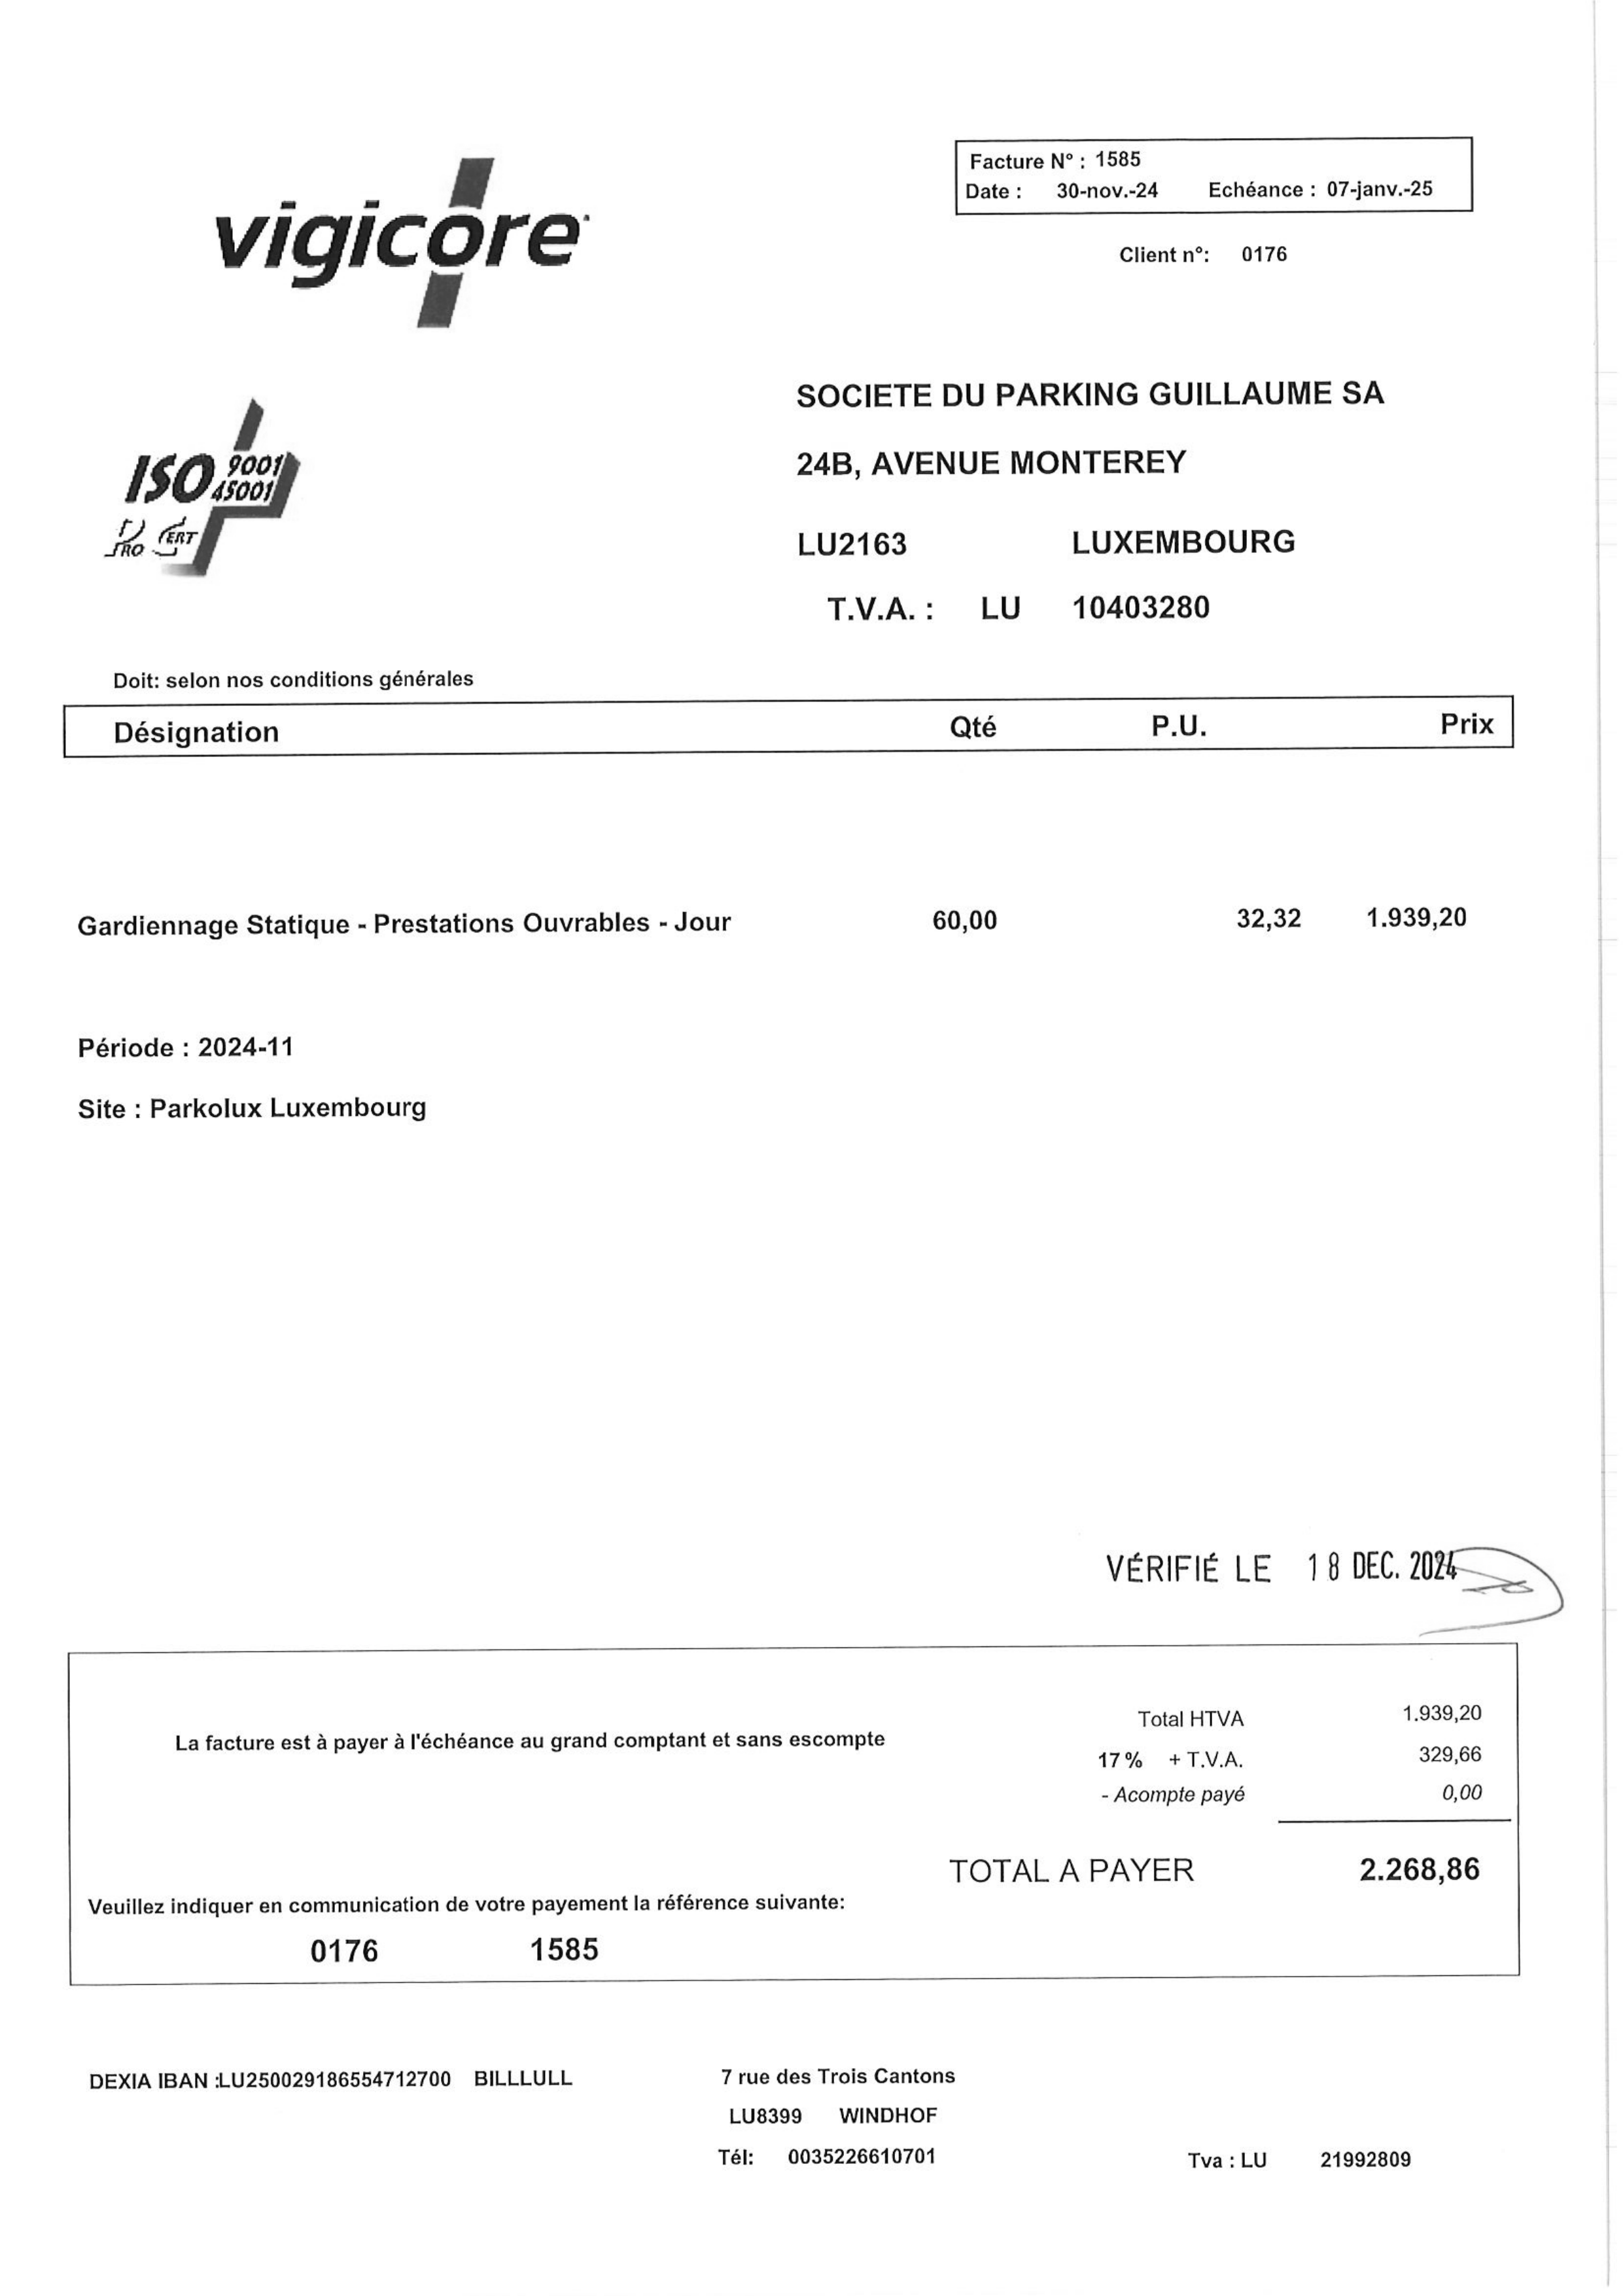

In [4]:
image_path_test = r"data\train\20241224093637635.pdf_16.png"
image_test = Image.open(image_path_test)
image_rgb = image_test.convert("RGB")
image_rgb_array = np.array(image_rgb)


#---------------test_de_hsv, hue,saturation,value

# conversion en HSV

#hsv = cv2.cvtColor(image_rgb_array, cv2.COLOR_RGB2HSV)









image_rgb_array = cv2.cvtColor(image_rgb_array, cv2.COLOR_RGB2GRAY)
Image.fromarray(image_rgb_array)

In [5]:
text_test = pytesseract.image_to_string(image_rgb_array,config="--psm 6")
# Print the extracted text
print(text_test)

Facture N°; 1585
- = t | Date:  30-nov.-24 Echéance : 07-janv.-25
vigicore Client n®: 0176
} SOCIETE DU PARKING GUILLAUME SA
ISO. 900}, 24B, AVENUE MONTEREY
A500),
fr
A Ger, LU2163 LUXEMBOURG
T.V.A.: LU 10403280
Doit: selon nos conditions générales
Désignation até P.U. Prix
Gardiennage Statique - Prestations Ouvrables ~- Jour 60,00 32,32 1.939,20
Période : 2024-11
Site : Parkolux Luxembourg
VERIFIE LE 18 DEC. i
a Total HTVA 1.939,20
La facture est a payer a I'échéance au grand comptant et sans escompte
17% +T.V.A, 329,66
- Acompte payé 0,00
TOTAL A PAYER 2.268,86
Veuillez indiquer en communication de votre payement la référence suivante:
0176 1585
DEXIA IBAN :LU250029186554712700 BILLLULL 7 rue des Trois Cantons
LU8399 WINDHOF
Tél: 0035226610701 Tva:LU 21992809



In [9]:
text_20 = clean_ocr_text(text_test)

score_process = rapidfuzz.process.extractOne(text_20,clean_ocr_text('LU14673765'))
score_partial_ratio = rapidfuzz.fuzz.partial_ratio(text_20,
                                                    clean_ocr_text("vigicore"))
print(f"score_process: {score_process}")
print(f"score_partial_ratio {score_partial_ratio}")

matches = rapidfuzz.process.extract("LU16825646", text_20.split(), scorer=rapidfuzz.fuzz.partial_ratio, score_cutoff=100)
print(matches)

score_process: ('l', 60.0, 0)
score_partial_ratio 100.0
[('25', 100.0, 11)]


In [259]:
clean_ocr_text("0_rue_de_bouillon")

'0 rue de bouillon'

In [272]:
tvas = re.findall(r'\blu\d{8}\b', text_20)
print(tvas)

['lu16825646', 'lu16970874']


In [258]:
print(text_20)

donnees fiscales lu xem bou rg

ntva national 00005133041
ntva intracommunautaire lu10355144

adresse dexpedition
service eaux soc du parking guillaume
338 rue de rollingergrund l 2442 luxembourg 2a b avenu f monterey
tel 4796 7007 l 2163 luxembourg
fax
email lecturevdllu
recette communale nom soc du parking guillaume

3 rue du laboratoire l 1911 luxembourg

tel paiements 4796 2020 lieu de consommation  0ruedebouillon 

tel domiciliations 4796 2919 1248 luxembourg 
fax 4796 7616

email recettevdllu etage  lieu eauparking

pay direct with  reference client
ooo payconiq hi

a mentionner dans toute correspondance oo    
numero facture d240024309 
numero client  c1004856 
numero objet 124800000006 j 
sere a ei cai eere 
factu re eau  eau usee luxembourg le 15012025
i
periode du decompte 23012024   31122024  
1
i
 fau eau usee  total
  montants en eur pie htva tva 3 ttc htva tva0 ttc ttc
 daecompte 37364 1121 38485 32424 000 32424 70909  
  acomptes deduits  31692  952  32644  27952 000  27